In [1]:
import pandas as pd
df = pd.read_csv("bank_transactions_data_2.csv")
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

In [2]:
df.groupby('AccountID')['TransactionID'].count()

AccountID
AC00001    2
AC00002    7
AC00003    5
AC00004    9
AC00005    9
          ..
AC00496    3
AC00497    6
AC00498    8
AC00499    7
AC00500    4
Name: TransactionID, Length: 495, dtype: int64

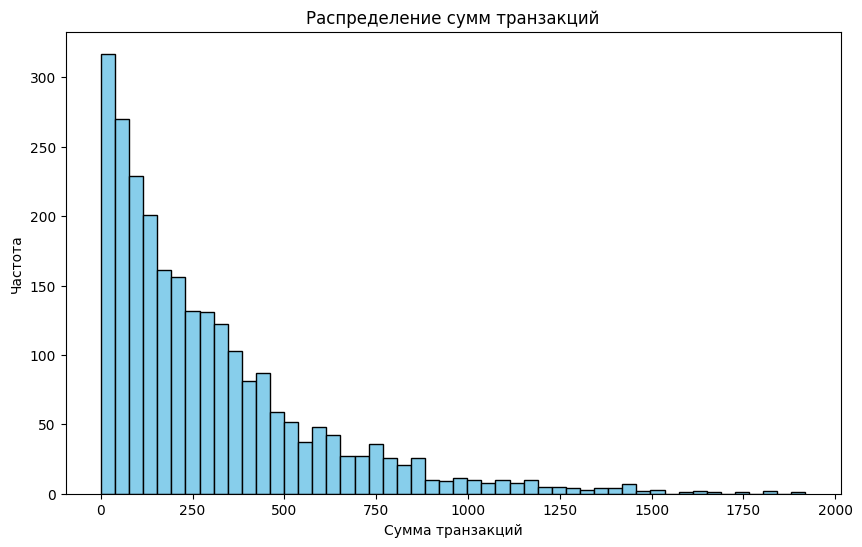

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['TransactionAmount'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Сумма транзакций')
plt.ylabel('Частота')
plt.title('Распределение сумм транзакций')
plt.show()

In [4]:
now=df['TransactionDate'].max()

rfm = df.groupby('AccountID').agg({
    'TransactionDate': lambda x : (now - x.max()),
    'TransactionID': 'count',
    'TransactionAmount': ['sum', 'mean', 'std'],
})

rfm.columns = ['Recency', 'TransactionCount', 'Sum_Amount', 'Avg_Amount', 'Std_Amount']

rfm


,Recency,TransactionCount,Sum_Amount,Avg_Amount,Std_Amount
AccountID,,,,,
AC00001,48 days 01:25:16,2,260.76,130.380000,116.799898
AC00002,11 days 01:21:00,7,2056.21,293.744286,195.695091
AC00003,90 days 23:24:31,5,1266.34,253.268000,158.484753
AC00004,0 days 02:13:01,9,2180.08,242.231111,231.081586
AC00005,28 days 00:19:57,9,3131.77,347.974444,189.487268
...,...,...,...,...,...
AC00496,250 days 00:26:39,3,595.88,198.626667,141.862904
AC00497,61 days 00:58:04,6,1187.21,197.868333,107.795494
AC00498,0 days 01:47:40,8,3051.02,381.377500,423.171694


In [5]:
behavior = df.groupby('AccountID').agg({
    'TransactionDuration': 'mean',
    'LoginAttempts': 'mean',
    'DeviceID': pd.Series.nunique,
    'IP Address': pd.Series.nunique
}) 
behavior

,TransactionDuration,LoginAttempts,DeviceID,IP Address
AccountID,,,,
AC00001,107.500000,1.000000,2,2
AC00002,109.857143,1.142857,7,7
AC00003,49.200000,1.000000,5,5
AC00004,104.333333,1.000000,9,9
AC00005,145.111111,1.000000,9,9
...,...,...,...,...
AC00496,92.666667,1.000000,3,3
AC00497,161.000000,1.000000,6,6
AC00498,131.625000,1.125000,8,8


In [6]:
demo = df.groupby('AccountID').agg({
    'CustomerAge': 'mean',
    'CustomerOccupation': 'first'
})

demo


,CustomerAge,CustomerOccupation
AccountID,,
AC00001,42.000000,Student
AC00002,51.857143,Retired
AC00003,56.600000,Doctor
AC00004,53.333333,Retired
AC00005,44.888889,Engineer
...,...,...
AC00496,38.666667,Doctor
AC00497,52.500000,Retired
AC00498,34.375000,Engineer


In [7]:
features = pd.concat([rfm, behavior, demo], axis=1)

In [8]:
features = pd.get_dummies(features, columns=['CustomerOccupation'], drop_first=True)
features.iloc[:, -3:] = features.iloc[:, -3:].astype(int)


C:\Users\administrator\AppData\Local\Temp\ipykernel_23308\550743572.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'AccountID
AC00001    0
AC00002    0
AC00003    0
AC00004    0
AC00005    1
          ..
AC00496    0
AC00497    0
AC00498    1
AC00499    1
AC00500    0
Name: CustomerOccupation_Engineer, Length: 495, dtype: int64' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  features.iloc[:, -3:] = features.iloc[:, -3:].astype(int)
C:\Users\administrator\AppData\Local\Temp\ipykernel_23308\550743572.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'AccountID
AC00001    0
AC00002    1
AC00003    0
AC00004    1
AC00005    0
          ..
AC00496    0
AC00497    1
AC00498    0
AC00499    0
AC00500    0
Name: CustomerOccupation_Retired, Length: 495, dtype: int64' has dtype incompatible with bool, please 

In [9]:
features['Recency'] = features['Recency'].dt.days.astype(float)

In [10]:
features.isna().sum()

Recency                         0
TransactionCount                0
Sum_Amount                      0
Avg_Amount                      0
Std_Amount                     24
TransactionDuration             0
LoginAttempts                   0
DeviceID                        0
IP Address                      0
CustomerAge                     0
CustomerOccupation_Engineer     0
CustomerOccupation_Retired      0
CustomerOccupation_Student      0
dtype: int64

In [11]:
users_with_nan_std = features[features['Std_Amount'].isna()]


users_with_nan_std['TransactionCount'].value_counts()

TransactionCount
1    24
Name: count, dtype: int64

In [12]:
features['Std_Amount'] = features['Std_Amount'].fillna(0)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
f_scaled = scaler.fit_transform(features) 

In [14]:
f_scaled

array([[-0.29864352, -1.34154674, -1.31860273, ..., -0.60302269,
        -0.54388557,  1.75809815],
       [-0.83821696,  0.84000923,  0.57621424, ..., -0.60302269,
         1.83862203, -0.56879646],
       [ 0.31384526, -0.03261316, -0.25737014, ..., -0.60302269,
        -0.54388557, -0.56879646],
       ...,
       [-0.99863069,  1.27632042,  1.62608078, ...,  1.6583124 ,
        -0.54388557, -0.56879646],
       [-0.48822337,  0.84000923,  0.85596477, ...,  1.6583124 ,
        -0.54388557, -0.56879646],
       [ 0.22634686, -0.46892435, -0.91102896, ..., -0.60302269,
        -0.54388557,  1.75809815]], shape=(495, 13))

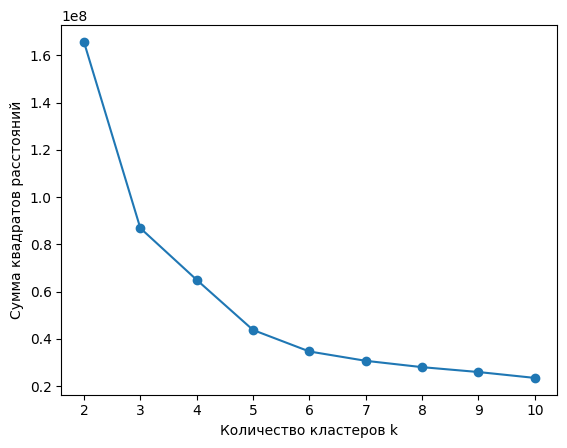

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(2, 11)  

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel('Количество кластеров k')
plt.ylabel('Сумма квадратов расстояний')
plt.show()

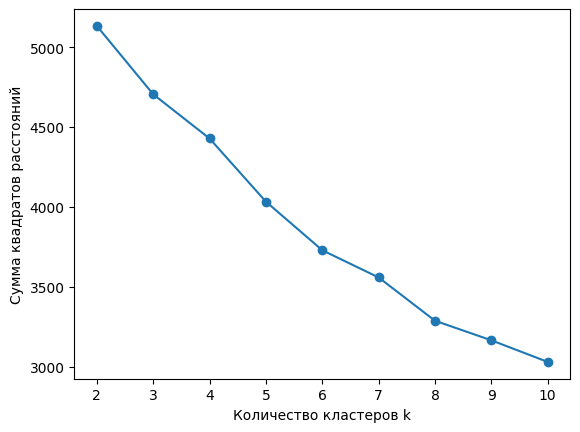

In [16]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(2, 11)  

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(f_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel('Количество кластеров k')
plt.ylabel('Сумма квадратов расстояний')
plt.show()

C:\Users\administrator\AppData\Local\Temp\ipykernel_23308\1973253283.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


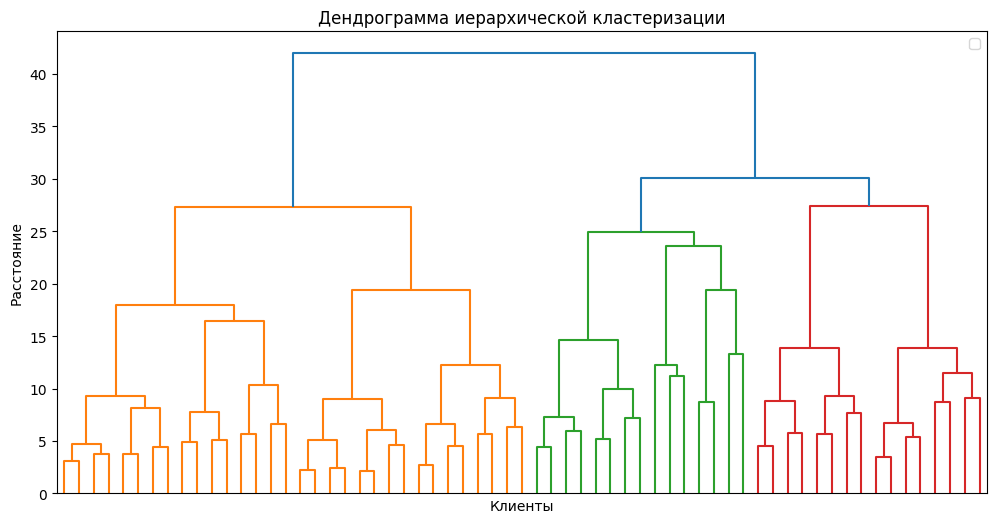

In [17]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))
linkage_matrix = linkage(f_scaled, method='ward')


dendrogram(linkage_matrix, truncate_mode='level', p=5, no_labels=True)
plt.xlabel('Клиенты')
plt.ylabel('Расстояние')
plt.title('Дендрограмма иерархической кластеризации')
plt.legend()
plt.show()

In [18]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(f_scaled)

features['Cluster'] = clusters


In [19]:
product_features = features.groupby('Cluster').mean()

In [20]:
features

,Recency,TransactionCount,Sum_Amount,Avg_Amount,Std_Amount,TransactionDuration,LoginAttempts,DeviceID,IP Address,CustomerAge,CustomerOccupation_Engineer,CustomerOccupation_Retired,CustomerOccupation_Student,Cluster
AccountID,,,,,,,,,,,,,,
AC00001,48.0,2,260.76,130.380000,116.799898,107.500000,1.000000,2,2,42.000000,0,0,1,2
AC00002,11.0,7,2056.21,293.744286,195.695091,109.857143,1.142857,7,7,51.857143,0,1,0,1
AC00003,90.0,5,1266.34,253.268000,158.484753,49.200000,1.000000,5,5,56.600000,0,0,0,3
AC00004,0.0,9,2180.08,242.231111,231.081586,104.333333,1.000000,9,9,53.333333,0,1,0,1
AC00005,28.0,9,3131.77,347.974444,189.487268,145.111111,1.000000,9,9,44.888889,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AC00496,250.0,3,595.88,198.626667,141.862904,92.666667,1.000000,3,3,38.666667,0,0,0,2
AC00497,61.0,6,1187.21,197.868333,107.795494,161.000000,1.000000,6,6,52.500000,0,1,0,3
AC00498,0.0,8,3051.02,381.377500,423.171694,131.625000,1.125000,8,8,34.375000,1,0,0,1


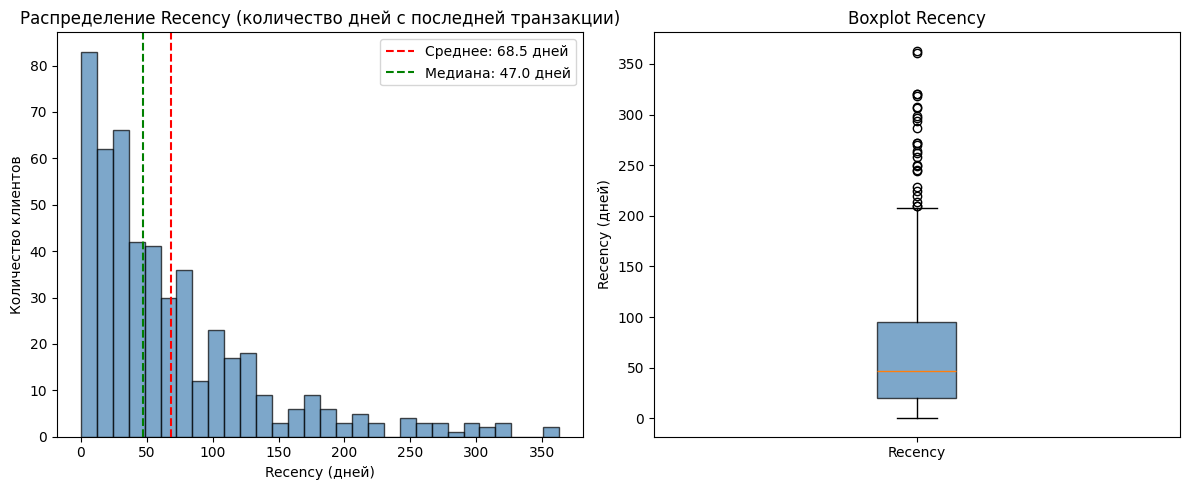

Статистика по recency
Среднее:           68.48 дней
Медиана:           47.00 дней
Минимум:           0.00 дней
Максимум:          363.00 дней
Станд. отклонение: 68.64 дней
Квартиль 25%:      20.00 дней
Квартиль 75%:      95.50 дней


In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


recency_days = features['Recency'].copy()


plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.hist(recency_days, bins=30, edgecolor='black', color='steelblue', alpha=0.7)
plt.axvline(recency_days.mean(), color='red', linestyle='--', label=f'Среднее: {recency_days.mean():.1f} дней')
plt.axvline(recency_days.median(), color='green', linestyle='--', label=f'Медиана: {recency_days.median():.1f} дней')
plt.xlabel('Recency (дней)')
plt.ylabel('Количество клиентов')
plt.title('Распределение Recency (количество дней с последней транзакции)')
plt.legend()


plt.subplot(1, 2, 2)
plt.boxplot(recency_days, vert=True, patch_artist=True, 
            boxprops=dict(facecolor='steelblue', alpha=0.7))
plt.ylabel('Recency (дней)')
plt.title('Boxplot Recency')
plt.xticks([1], ['Recency'])

plt.tight_layout()
plt.show()

print("Статистика по recency")

print(f"Среднее:           {recency_days.mean():.2f} дней")
print(f"Медиана:           {recency_days.median():.2f} дней")
print(f"Минимум:           {recency_days.min():.2f} дней")
print(f"Максимум:          {recency_days.max():.2f} дней")
print(f"Станд. отклонение: {recency_days.std():.2f} дней")
print(f"Квартиль 25%:      {recency_days.quantile(0.25):.2f} дней")
print(f"Квартиль 75%:      {recency_days.quantile(0.75):.2f} дней")

In [21]:
results = []


for cluster_id in features['Cluster'].unique():
    cluster_data = features[features['Cluster'] == cluster_id]
    
    churn_rate = (cluster_data['Recency'] > 60).mean()
    retention_rate = (cluster_data['Recency'] <= 60).mean()
    
 
    results.append({
        'Cluster': cluster_id,
        'churn_rate': churn_rate,
        'retention_rate': retention_rate
    })


churn_retention_df = pd.DataFrame(results)
churn_retention_df = churn_retention_df.sort_values(by='Cluster')
churn_retention_df.reset_index(drop=True)

,Cluster,churn_rate,retention_rate
0,0,0.589744,0.410256
1,1,0.191257,0.808743
2,2,0.730000,0.270000
3,3,0.404624,0.595376


In [22]:
clusters_size=features.groupby('Cluster').size().reset_index(name='count')
clusters_size

,Cluster,count
0,0,39
1,1,183
2,2,100
3,3,173


In [23]:
product = clusters_size.merge(churn_retention_df, on='Cluster')
product = product.merge(product_features, on='Cluster')
product

,Cluster,count,churn_rate,retention_rate,Recency,TransactionCount,Sum_Amount,Avg_Amount,Std_Amount,TransactionDuration,LoginAttempts,DeviceID,IP Address,CustomerAge,CustomerOccupation_Engineer,CustomerOccupation_Retired,CustomerOccupation_Student
0,0,39,0.589744,0.410256,67.871795,4.641026,1234.628205,268.092293,236.181228,128.236447,1.884921,4.641026,4.641026,43.239621,0.333333,0.179487,0.153846
1,1,183,0.191257,0.808743,39.617486,7.387978,2366.151694,327.530068,297.257782,122.107791,1.100821,7.338798,7.338798,43.927403,0.289617,0.191257,0.289617
2,2,100,0.730000,0.270000,135.040000,2.900000,561.962300,196.683445,116.013652,133.335833,1.018833,2.900000,2.900000,40.492833,0.220000,0.060000,0.490000
3,3,173,0.404624,0.595376,60.670520,3.982659,1215.046705,320.125991,269.360634,108.034008,1.021869,3.965318,3.959538,47.992004,0.254335,0.375723,0.075145


In [24]:

print(df['TransactionDate'].min())
print(df['TransactionDate'].max())

date_range = df['TransactionDate'].max() - df['TransactionDate'].min()
print(date_range.days)

2023-01-02 16:00:06
2024-01-01 18:21:50
364
